In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sb

In [19]:
non_outlier_df = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\non_outlier_df.csv")

In [20]:
scaled_df = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\scaled_data_df.csv")

In [21]:
scaled_df.head(5)

,Monetary_value,Frequency,Recency
0,0.962463,0.847217,0.791534
1,0.976476,-0.997144,-1.309204
2,-0.619220,-0.997144,0.973128
3,0.926025,1.793266,-0.797532
4,-1.806869,-0.997144,0.626475


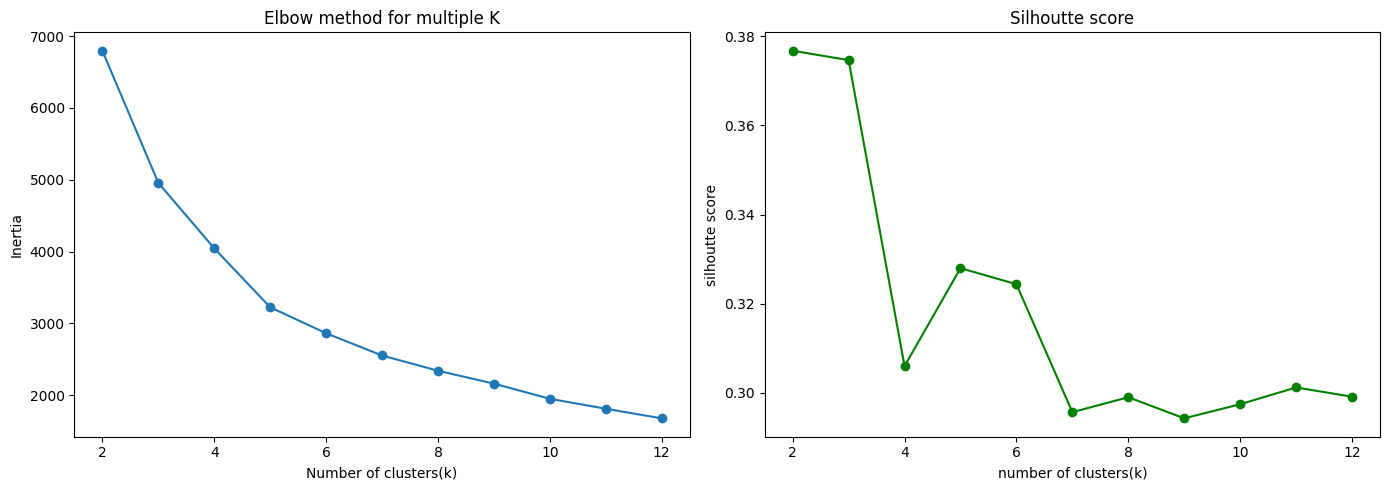

In [22]:
# Find the cluster(k-number) using elbow method / silhoutte score

inertia = []
sil_scores = []
k_range = range(2,13) 

for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42,max_iter=1000)
    cluster_label = kmeans.fit_predict(scaled_df)
    inertia.append(kmeans.inertia_)
    sil_score = silhouette_score(scaled_df,cluster_label)
    sil_scores.append(sil_score)

fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(k_range,inertia,marker="o")
ax[0].set_title("Elbow method for multiple K")
ax[0].set_xlabel("Number of clusters(k)")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_range,sil_scores,marker="o",color="green")
ax[1].set_title("Silhoutte score")
ax[1].set_xlabel("number of clusters(k)")
ax[1].set_ylabel("silhoutte score")

plt.tight_layout()
plt.show()

 # interpretation for finding cluster k number
 
 - k = 3 indicate the best k number as it show biggest bend in  elbow and the highest silhoutte score  

In [35]:
# Input the k=3 into the kmeans and run the model
k = 3
kmeans = KMeans(n_clusters=3,random_state=10,max_iter=1000,n_init=10)
non_outlier_df["Cluster"] = kmeans.fit_predict(scaled_df)
non_outlier_df

,Customer ID,Country,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency,Cluster
0,12348.0,Finland,1437.24,4,2011-04-05 10:47:00,2011-12-10 12:50:00,249,1
1,12349.0,Italy,1457.55,1,2011-11-21 09:51:00,2011-12-10 12:50:00,19,0
2,12350.0,Norway,294.40,1,2011-02-02 16:01:00,2011-12-10 12:50:00,310,2
3,12352.0,Norway,1385.74,7,2011-11-03 14:37:00,2011-12-10 12:50:00,36,1
4,12353.0,Bahrain,89.00,1,2011-05-19 17:47:00,2011-12-10 12:50:00,204,2
...,...,...,...,...,...,...,...,...
3858,18278.0,United Kingdom,173.90,1,2011-09-27 11:58:00,2011-12-10 12:50:00,74,2
3859,18280.0,United Kingdom,180.60,1,2011-03-07 09:52:00,2011-12-10 12:50:00,278,2
3860,18281.0,United Kingdom,80.82,1,2011-06-12 10:53:00,2011-12-10 12:50:00,181,2
3861,18282.0,United Kingdom,178.05,2,2011-08-05 13:35:00,2011-12-10 12:50:00,126,2


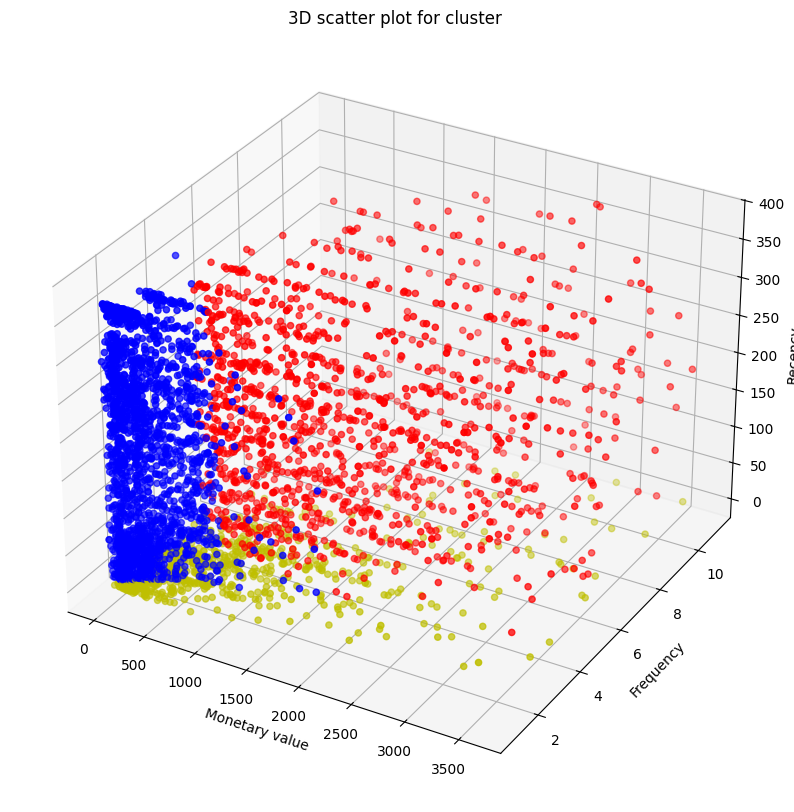

In [37]:
# Visualised the cluster with 3d scatter plot

cluster_colours = {
    0: "y",
    1: "r",
    2: "b",
}

colors = non_outlier_df["Cluster"].map(cluster_colours)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(non_outlier_df["Total_sales"], non_outlier_df["Frequency"],non_outlier_df["Recency"], c=colors,marker="o")
ax.set_title("3D scatter plot for cluster")
ax.set_xlabel("Monetary value")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
plt.show()


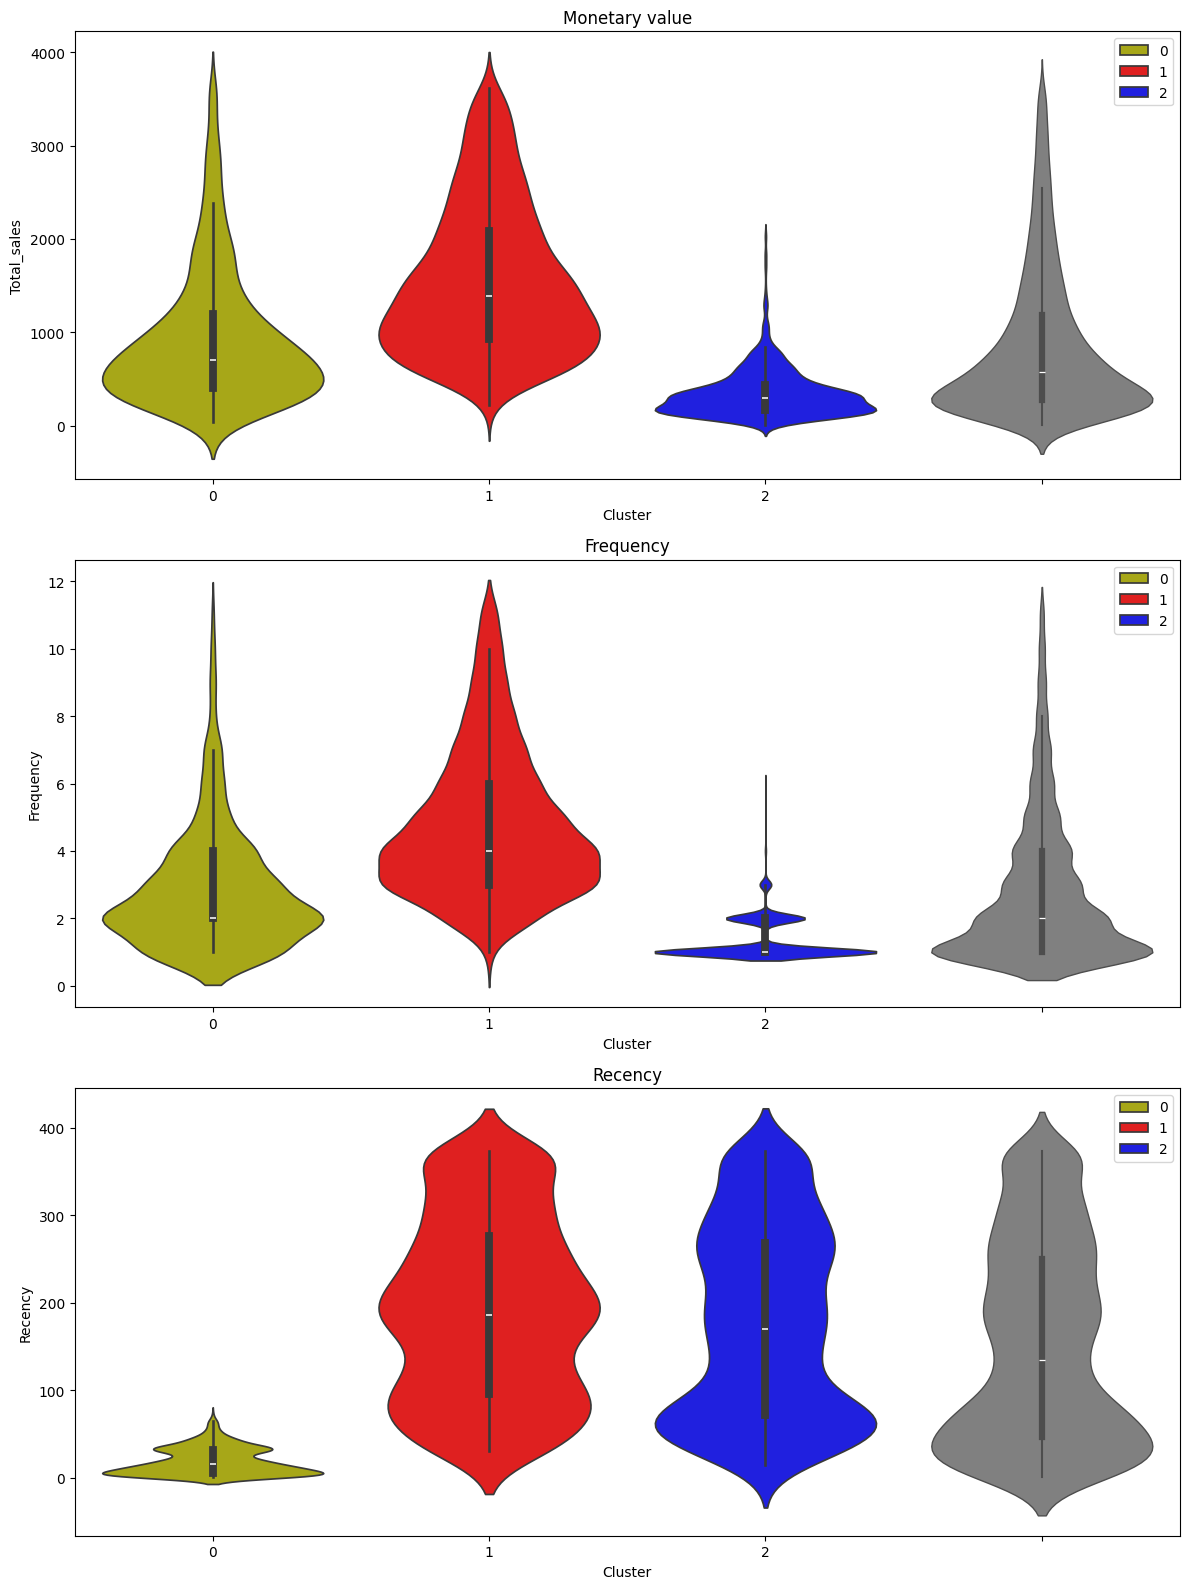

In [38]:
# Visualise each cluster's distribution using violin plot 
# Understanding cluster distribution help in indentify clsuter label 

plt.figure(figsize=(12,16))
plt.subplot(3,1,1)
sb.violinplot(x=non_outlier_df["Cluster"],y=non_outlier_df["Total_sales"],palette=cluster_colours,hue=non_outlier_df["Cluster"])
sb.violinplot(y=non_outlier_df["Total_sales"],color="grey",linewidth=1.0) # this is the reference monetary value for all customer without grouping by cluster
plt.title("Monetary value")

plt.subplot(3,1,2)
sb.violinplot(x=non_outlier_df["Cluster"],y=non_outlier_df["Frequency"],palette=cluster_colours,hue=non_outlier_df["Cluster"])
sb.violinplot(y=non_outlier_df["Frequency"],color="grey",linewidth=1.0) # this is the reference frequency for all customer without grouping by cluster
plt.title("Frequency")

plt.subplot(3,1,3)
sb.violinplot(x=non_outlier_df["Cluster"],y=non_outlier_df["Recency"],palette=cluster_colours,hue=non_outlier_df["Cluster"])
sb.violinplot(y=non_outlier_df["Recency"],color="grey",linewidth=1.0) # this is the reference recency for all customer without grouping by cluster
plt.title("Recency")

plt.tight_layout()
plt.show()

# Interpretation of Non Outlier Violinplot 

1. Cluster 0 (yellow) = Average monetary value , low frequency , low recency which indicate Average monetary value new customer or inactive re-entry customer with recent purchase (New customer/Inactive customer)
- Solution: Focus on building relationship with these group of customer and provide good customer service with provide incentive to encourage more frequent purchase. 

2. Cluster 1 (red)    = High monetary value, average frequency, high recency which indicate infrequent high value customer with recent purchase (key customer)
- Solution: Reward program for loyalty customer 

3. Cluster 2 (blue)   = low monetary value, low frequency, high recency which indicate dormant low value customer with no recent purchase (dormant customer)
- Solution: Re-engage program 

In [39]:
monetary_outliers = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\Monetary_outlier_df.csv")
frequency_outliers = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\Artifact\\Frequency_outlier_df.csv")

In [40]:
# Outlier Analysis to clustering the outlier  
overlap_indices = monetary_outliers.index.intersection(frequency_outliers.index)

monetary_only_outliers = monetary_outliers.drop(overlap_indices)
frequency_only_outliers = frequency_outliers.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers.loc[overlap_indices]

# Manually map the label to cluster
monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] =-2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_cluster_df = pd.concat([monetary_only_outliers,frequency_only_outliers,monetary_and_frequency_outliers])

outlier_cluster_df

,Customer ID,Country,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency,Cluster
278,15971.0,United Kingdom,4194.90,12,2011-07-06 12:33:00,2011-12-10 12:50:00,157,-1
279,16000.0,United Kingdom,12393.70,3,2011-12-07 12:17:00,2011-12-10 12:50:00,3,-1
280,16013.0,United Kingdom,37130.60,47,2011-06-08 13:00:00,2011-12-10 12:50:00,184,-1
281,16019.0,United Kingdom,3786.24,9,2011-01-07 10:00:00,2011-12-10 12:50:00,337,-1
282,16029.0,United Kingdom,72882.09,62,2011-07-08 11:41:00,2011-12-10 12:50:00,155,-1
...,...,...,...,...,...,...,...,...
273,15867.0,United Kingdom,3806.10,15,2011-06-09 16:08:00,2011-12-10 12:50:00,183,-3
274,15874.0,United Kingdom,4405.88,7,2011-04-08 12:17:00,2011-12-10 12:50:00,246,-3
275,15903.0,United Kingdom,5126.76,7,2011-09-30 13:31:00,2011-12-10 12:50:00,70,-3
276,15939.0,United Kingdom,6100.01,14,2011-04-07 12:02:00,2011-12-10 12:50:00,247,-3


In [41]:
print(monetary_only_outliers.shape)
print(frequency_only_outliers.shape)
print(monetary_and_frequency_outliers.shape)

(147, 8)
(0, 8)
(278, 8)


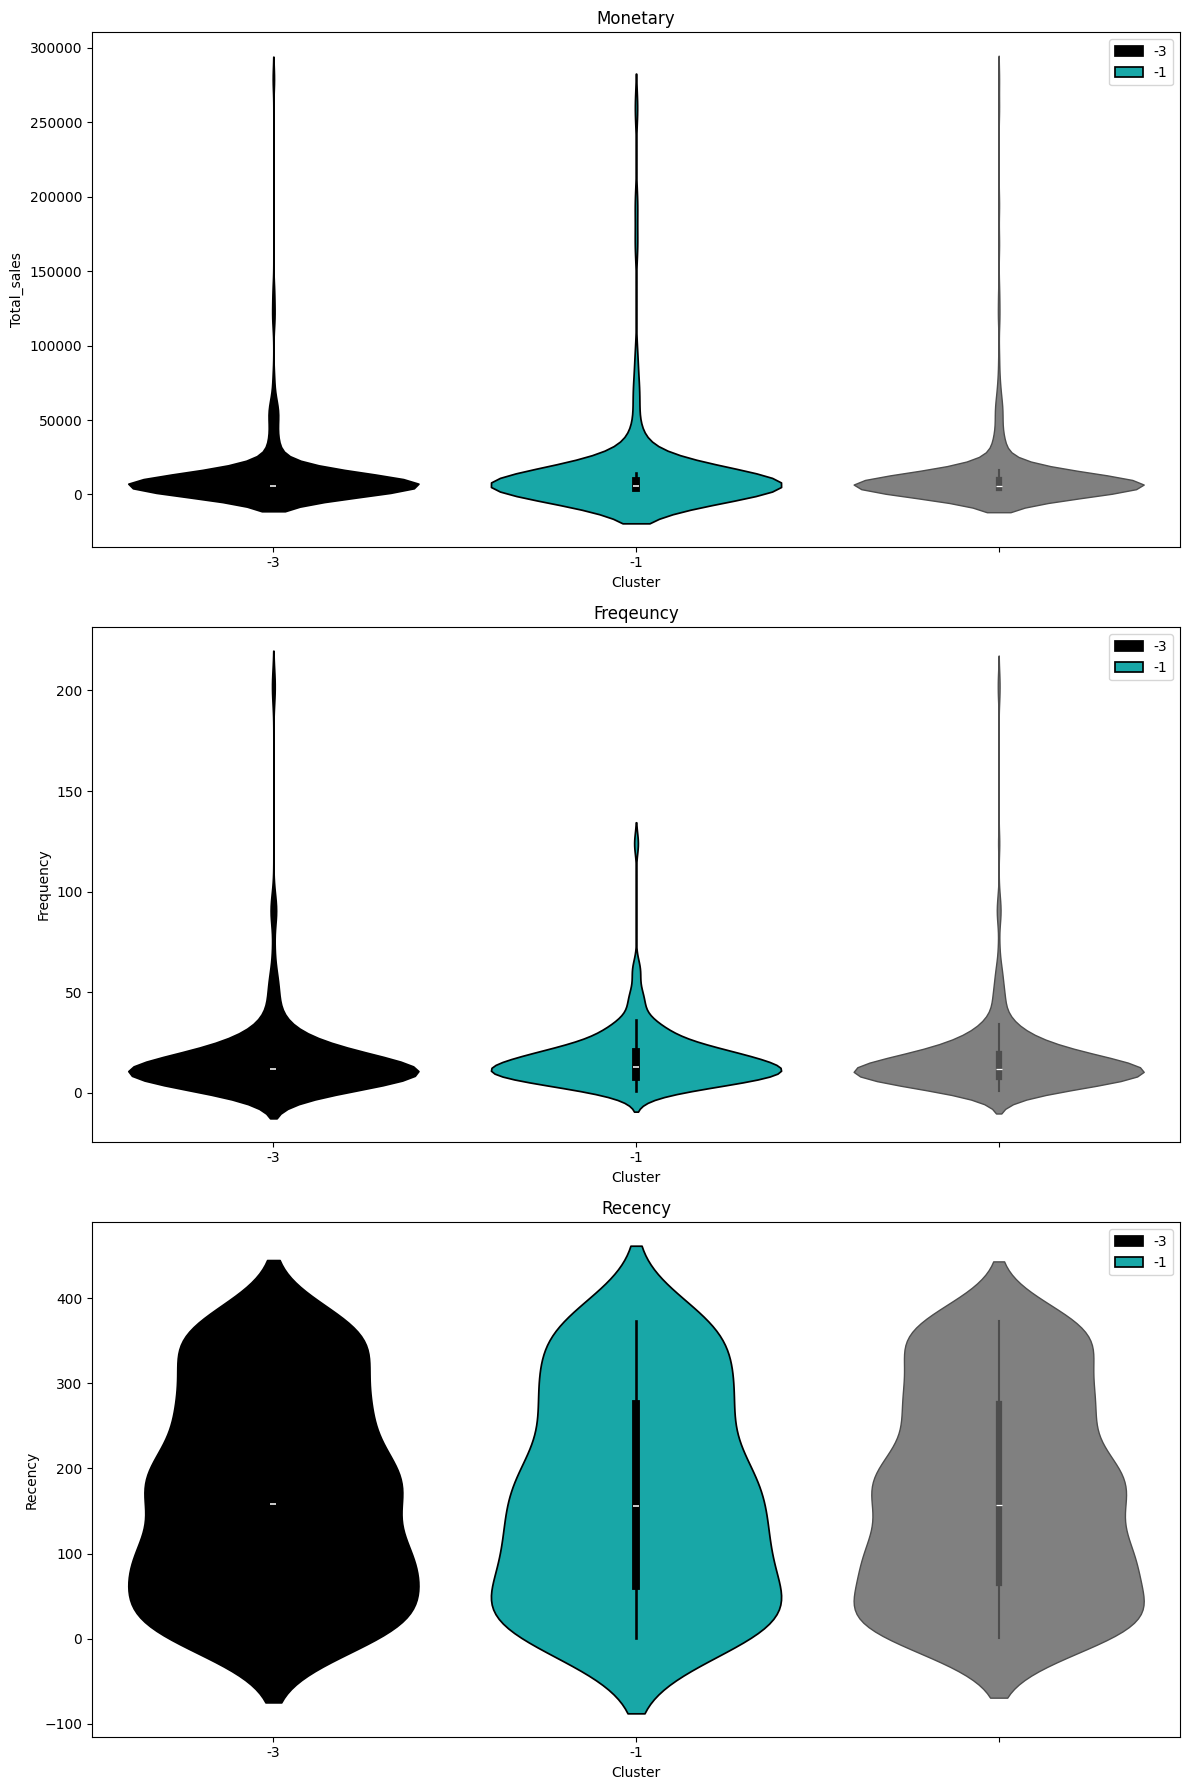

In [42]:
# visualise the outlier with distribution in violinplot 

cluster_colours = {
    -1:'c',
    -2:"m",
    -3:"k"
}

plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sb.violinplot(x=outlier_cluster_df["Cluster"],y=outlier_cluster_df["Total_sales"],palette=cluster_colours,hue=outlier_cluster_df["Cluster"])
sb.violinplot(y=outlier_cluster_df["Total_sales"],color="grey",linewidth=1.0)
plt.title("Monetary")

plt.subplot(3,1,2)
sb.violinplot(x=outlier_cluster_df["Cluster"],y=outlier_cluster_df["Frequency"],palette=cluster_colours,hue=outlier_cluster_df["Cluster"])
sb.violinplot(y=outlier_cluster_df["Frequency"],color="grey",linewidth=1.0)
plt.title("Freqeuncy")

plt.subplot(3,1,3)
sb.violinplot(x=outlier_cluster_df["Cluster"],y=outlier_cluster_df["Recency"],palette=cluster_colours,hue=outlier_cluster_df["Cluster"])
sb.violinplot(y=outlier_cluster_df["Recency"],color="grey",linewidth=1.0)
plt.title("Recency")

plt.tight_layout()
plt.show()


In [43]:
outlier_cluster_df["Cluster"].value_counts()

Cluster
-3    278
-1    147
Name: count, dtype: int64

# Interpretation of outlier violinplot

- -2 Cluster disappear because of all frequency outlier is intersect with monetary outlier

- -1 Cluster (cyan) = extreme high spending customer group but not necessarily frequent buyer which indicate large purchases but infrequent (VIP).  

Solution: Focus on maintaining their loyalty with personalized offer or luxury services that cater their high spending capacity

- -3 Cluster (black) = Extreme high spending and infrequent purchase which indicate they are top-tier most valuable customer who require special attention (champion).  

Solution: Develop exclusive VIP program to maintain loyalty and encourage continued engagement.  

In [31]:
cluster_labels = {
    0:"New customer",
    1:"Key customer",
    2:"Dormant",
    3:"Occasional",
    -1:"VIP",
    -3: "Champion"
}

In [44]:
full_clustering_df = pd.concat([non_outlier_df,outlier_cluster_df])
full_clustering_df

,Customer ID,Country,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency,Cluster
0,12348.0,Finland,1437.24,4,2011-04-05 10:47:00,2011-12-10 12:50:00,249,1
1,12349.0,Italy,1457.55,1,2011-11-21 09:51:00,2011-12-10 12:50:00,19,0
2,12350.0,Norway,294.40,1,2011-02-02 16:01:00,2011-12-10 12:50:00,310,2
3,12352.0,Norway,1385.74,7,2011-11-03 14:37:00,2011-12-10 12:50:00,36,1
4,12353.0,Bahrain,89.00,1,2011-05-19 17:47:00,2011-12-10 12:50:00,204,2
...,...,...,...,...,...,...,...,...
273,15867.0,United Kingdom,3806.10,15,2011-06-09 16:08:00,2011-12-10 12:50:00,183,-3
274,15874.0,United Kingdom,4405.88,7,2011-04-08 12:17:00,2011-12-10 12:50:00,246,-3
275,15903.0,United Kingdom,5126.76,7,2011-09-30 13:31:00,2011-12-10 12:50:00,70,-3
276,15939.0,United Kingdom,6100.01,14,2011-04-07 12:02:00,2011-12-10 12:50:00,247,-3


In [33]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)
full_clustering_df

,Customer ID,Country,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency,Cluster,ClusterLabel
0,12348.0,Finland,1437.24,4,2011-04-05 10:47:00,2011-12-10 12:50:00,249,1,Key customer
1,12349.0,Italy,1457.55,1,2011-11-21 09:51:00,2011-12-10 12:50:00,19,3,Occasional
2,12350.0,Norway,294.40,1,2011-02-02 16:01:00,2011-12-10 12:50:00,310,0,New customer
3,12352.0,Norway,1385.74,7,2011-11-03 14:37:00,2011-12-10 12:50:00,36,2,Dormant
4,12353.0,Bahrain,89.00,1,2011-05-19 17:47:00,2011-12-10 12:50:00,204,0,New customer
...,...,...,...,...,...,...,...,...,...
273,15867.0,United Kingdom,3806.10,15,2011-06-09 16:08:00,2011-12-10 12:50:00,183,-3,Champion
274,15874.0,United Kingdom,4405.88,7,2011-04-08 12:17:00,2011-12-10 12:50:00,246,-3,Champion
275,15903.0,United Kingdom,5126.76,7,2011-09-30 13:31:00,2011-12-10 12:50:00,70,-3,Champion
276,15939.0,United Kingdom,6100.01,14,2011-04-07 12:02:00,2011-12-10 12:50:00,247,-3,Champion


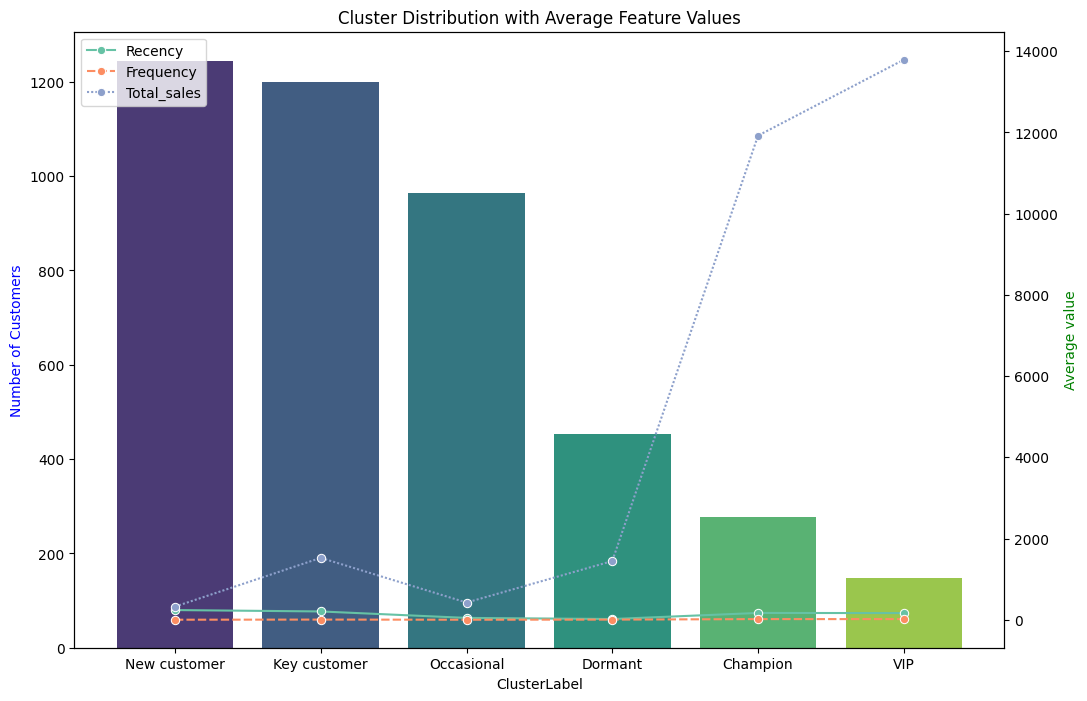

In [34]:
# Visualisation 

cluster_counts = full_clustering_df["ClusterLabel"].value_counts()
feature_means = full_clustering_df.groupby("ClusterLabel")[["Recency","Frequency","Total_sales"]].mean()

fig,ax1 = plt.subplots(figsize=(12,8))

sb.barplot(x=cluster_counts.index,y=cluster_counts.values,ax=ax1,palette="viridis",hue=cluster_counts.index)
ax1.set_ylabel("Number of Customers",color="b")
ax1.set_title("Cluster Distribution with Average Feature Values")

ax2 = ax1.twinx()

sb.lineplot(data=feature_means,ax=ax2,palette="Set2",marker="o")
ax2.set_ylabel("Average value",color="g")

plt.show()